In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pd.__version__

'3.0.2'

In [4]:
df = pd.read_csv("Ecommerce_Cust_Behavior_Data.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Validation_Flag,Order_Year,Order_Quarter,Order_MonthName,Day_of_Week,Age_Group,Discount_Flag,Discount_Rate_%,Recency,Frequency
0,ORD_000001-1,CUST_00001,5/29/2023,40,Male,Ankara,Books,29.18,1,0.00,...,OK,2023,Q2,May,Monday,36–50,False,0.000000,111,3
1,ORD_000001-2,CUST_00001,10/12/2023,40,Male,Ankara,Home & Garden,644.40,1,138.05,...,OK,2023,Q4,October,Thursday,36–50,True,21.423029,111,3
2,ORD_000001-3,CUST_00001,12/5/2023,40,Male,Ankara,Sports,332.82,5,0.00,...,OK,2023,Q4,December,Tuesday,36–50,False,0.000000,111,3
3,ORD_000002-1,CUST_00002,5/11/2023,33,Male,Istanbul,Food,69.30,5,71.05,...,OK,2023,Q2,May,Thursday,26–35,True,20.505051,283,2
4,ORD_000002-2,CUST_00002,6/16/2023,33,Male,Istanbul,Beauty,178.15,3,0.00,...,OK,2023,Q2,June,Friday,26–35,False,0.000000,283,2


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
last_purchase = df.groupby('Customer_ID')['Date'].max().reset_index()

In [7]:
last_purchase.columns = ['Customer_ID', 'Last_Purchase_Date']

In [8]:
df = df.merge(last_purchase, on='Customer_ID', how='left')

In [9]:
df['Recency'] = (df['Last_Purchase_Date'].max() - df['Last_Purchase_Date']).dt.days

In [10]:
df['Churn'] = df['Recency'].apply(lambda x: 1 if x > 90 else 0)

In [11]:
df[['Customer_ID', 'Last_Purchase_Date', 'Recency', 'Churn']].head()

,Customer_ID,Last_Purchase_Date,Recency,Churn
0,CUST_00001,2023-12-05,111,1
1,CUST_00001,2023-12-05,111,1
2,CUST_00001,2023-12-05,111,1
3,CUST_00002,2023-06-16,283,1
4,CUST_00002,2023-06-16,283,1


In [12]:
df['Churn'].value_counts()

Churn
0    10476
1     6573
Name: count, dtype: int64

In [13]:
df['Churn'].value_counts(normalize=True) * 100

Churn
0    61.446419
1    38.553581
Name: proportion, dtype: float64

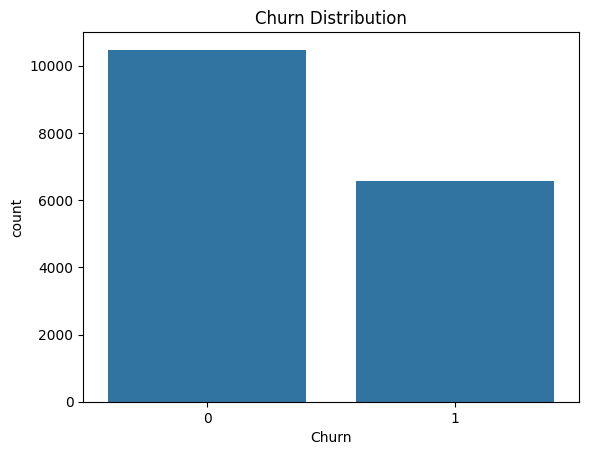

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

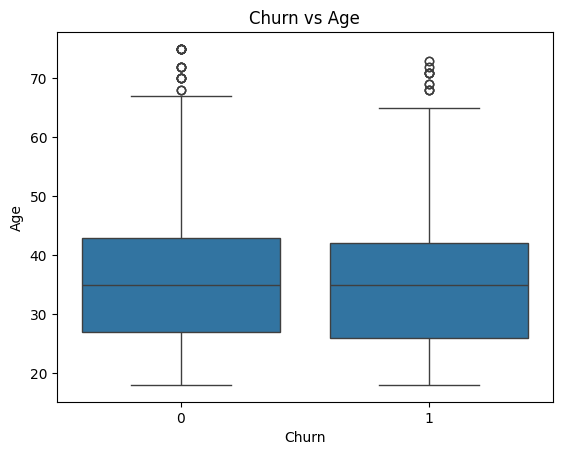

In [15]:
sns.boxplot(x='Churn', y='Age', data=df)
plt.title("Churn vs Age")
plt.show()

In [16]:
df['Total_Spend'] = df['Unit_Price'] * df['Quantity']

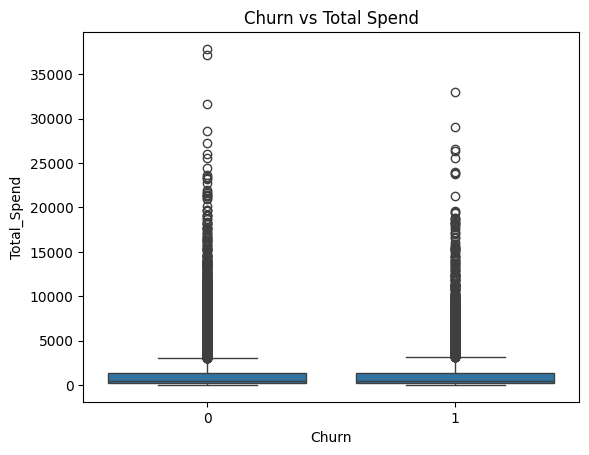

In [17]:
sns.boxplot(x='Churn', y='Total_Spend', data=df)
plt.title("Churn vs Total Spend")
plt.show()

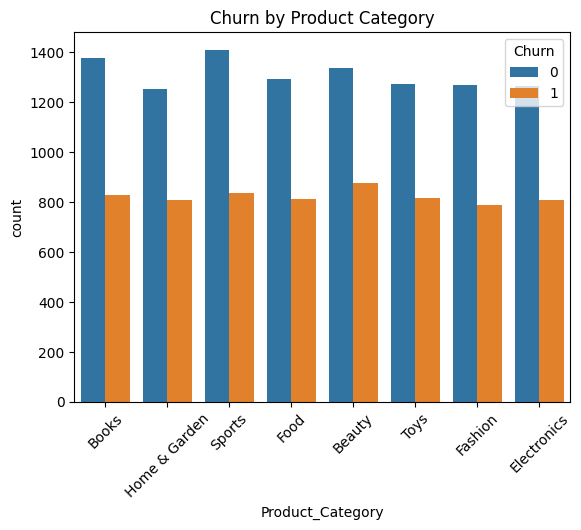

In [18]:
sns.countplot(x='Product_Category', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Product Category")
plt.show()

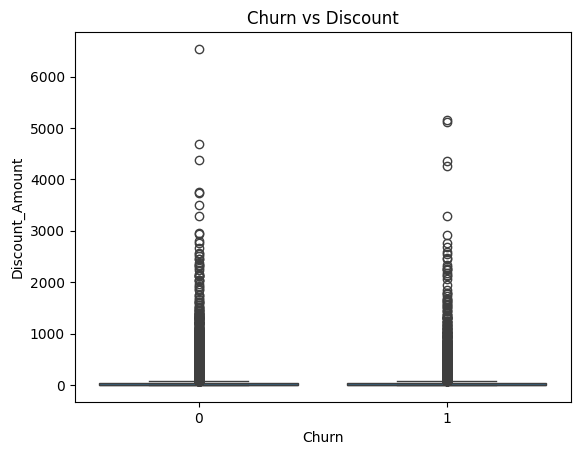

In [19]:
sns.boxplot(x='Churn', y='Discount_Amount', data=df)
plt.title("Churn vs Discount")
plt.show()

In [20]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Order_MonthName,Day_of_Week,Age_Group,Discount_Flag,Discount_Rate_%,Recency,Frequency,Last_Purchase_Date,Churn,Total_Spend
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,...,May,Monday,36–50,False,0.000000,111,3,2023-12-05,1,29.18
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,...,October,Thursday,36–50,True,21.423029,111,3,2023-12-05,1,644.40
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,...,December,Tuesday,36–50,False,0.000000,111,3,2023-12-05,1,1664.10
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,...,May,Thursday,26–35,True,20.505051,283,2,2023-06-16,1,346.50
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,...,June,Friday,26–35,False,0.000000,283,2,2023-06-16,1,534.45


In [21]:
customer_df = df.groupby('Customer_ID').agg({
    'Order_ID': 'nunique',
    'Total_Amount': 'sum',
    'Discount_Amount': 'mean',
    'Session_Duration_Minutes': 'mean',
    'Pages_Viewed': 'mean',
    'Delivery_Time_Days': 'mean',
    'Customer_Rating': 'mean',
    'Product_Category': 'nunique',
    'Age': 'first',
    'Is_Returning_Customer': 'first'
}).reset_index()

In [22]:
customer_df.columns = [
    'Customer_ID',
    'frequency',
    'monetary',
    'avg_discount_amount',
    'avg_session_duration',
    'avg_pages_viewed',
    'avg_delivery_days',
    'avg_rating_given',
    'n_categories_purchased',
    'age',
    'is_returning'
]

In [23]:
customer_df['avg_order_value'] = customer_df['monetary'] / customer_df['frequency']

In [24]:
recency_df = df.groupby('Customer_ID')['Recency'].first().reset_index()
recency_df.columns = ['Customer_ID', 'recency_days']

customer_df = customer_df.merge(recency_df, on='Customer_ID', how='left')

In [25]:
churn_df = df.groupby('Customer_ID')['Churn'].first().reset_index()

customer_df = customer_df.merge(churn_df, on='Customer_ID', how='left')

In [26]:
customer_df.head()

,Customer_ID,frequency,monetary,avg_discount_amount,avg_session_duration,avg_pages_viewed,avg_delivery_days,avg_rating_given,n_categories_purchased,age,is_returning,avg_order_value,recency_days,Churn
0,CUST_00001,3,2199.63,46.016667,14.333333,9.000000,9.333333,3.333333,3,40,True,733.210000,111,1
1,CUST_00002,2,809.90,35.525000,15.000000,10.000000,5.000000,4.000000,2,33,True,404.950000,283,1
2,CUST_00003,2,3030.81,0.000000,10.500000,8.500000,6.000000,3.500000,2,42,False,1515.405000,82,0
3,CUST_00004,1,383.22,97.780000,16.000000,15.000000,4.000000,5.000000,1,53,False,383.220000,41,0
4,CUST_00005,3,2422.73,0.000000,12.666667,9.333333,5.666667,3.666667,3,32,False,807.576667,278,1


In [27]:
customer_df.shape

(5000, 14)

In [28]:
gender_df = df.groupby('Customer_ID')['Gender'].first().reset_index()
gender_df['gender_encoded'] = gender_df['Gender'].map({
    'Male': 1,
    'Female': 0
})

customer_df = customer_df.merge(
    gender_df[['Customer_ID', 'gender_encoded']],
    on='Customer_ID',
    how='left'
)

In [29]:
payment_df = df.groupby('Customer_ID')['Payment_Method'].agg(
    lambda x: x.mode()[0]
).reset_index()

payment_df.columns = ['Customer_ID', 'preferred_payment']

customer_df = customer_df.merge(
    payment_df,
    on='Customer_ID',
    how='left'
)

In [30]:
mobile_df = df.groupby('Customer_ID')['Device_Type'].apply(
    lambda x: (x == 'Mobile').mean() * 100
).reset_index()

mobile_df.columns = ['Customer_ID', 'pct_mobile_orders']

customer_df = customer_df.merge(
    mobile_df,
    on='Customer_ID',
    how='left'
)

In [31]:
discount_df = df.groupby('Customer_ID')['Discount_Amount'].apply(
    lambda x: (x > 0).mean() * 100
).reset_index()

discount_df.columns = ['Customer_ID', 'pct_orders_discounted']

customer_df = customer_df.merge(
    discount_df,
    on='Customer_ID',
    how='left'
)

In [32]:
customer_df.head()

,Customer_ID,frequency,monetary,avg_discount_amount,avg_session_duration,avg_pages_viewed,avg_delivery_days,avg_rating_given,n_categories_purchased,age,is_returning,avg_order_value,recency_days,Churn,gender_encoded,preferred_payment,pct_mobile_orders,pct_orders_discounted
0,CUST_00001,3,2199.63,46.016667,14.333333,9.000000,9.333333,3.333333,3,40,True,733.210000,111,1,1.0,Credit Card,66.666667,33.333333
1,CUST_00002,2,809.90,35.525000,15.000000,10.000000,5.000000,4.000000,2,33,True,404.950000,283,1,1.0,Credit Card,50.000000,50.000000
2,CUST_00003,2,3030.81,0.000000,10.500000,8.500000,6.000000,3.500000,2,42,False,1515.405000,82,0,1.0,Credit Card,0.000000,0.000000
3,CUST_00004,1,383.22,97.780000,16.000000,15.000000,4.000000,5.000000,1,53,False,383.220000,41,0,1.0,Credit Card,0.000000,100.000000
4,CUST_00005,3,2422.73,0.000000,12.666667,9.333333,5.666667,3.666667,3,32,False,807.576667,278,1,1.0,Credit Card,66.666667,0.000000


In [33]:
customer_df.shape

(5000, 18)

In [34]:
customer_df.head()

,Customer_ID,frequency,monetary,avg_discount_amount,avg_session_duration,avg_pages_viewed,avg_delivery_days,avg_rating_given,n_categories_purchased,age,is_returning,avg_order_value,recency_days,Churn,gender_encoded,preferred_payment,pct_mobile_orders,pct_orders_discounted
0,CUST_00001,3,2199.63,46.016667,14.333333,9.000000,9.333333,3.333333,3,40,True,733.210000,111,1,1.0,Credit Card,66.666667,33.333333
1,CUST_00002,2,809.90,35.525000,15.000000,10.000000,5.000000,4.000000,2,33,True,404.950000,283,1,1.0,Credit Card,50.000000,50.000000
2,CUST_00003,2,3030.81,0.000000,10.500000,8.500000,6.000000,3.500000,2,42,False,1515.405000,82,0,1.0,Credit Card,0.000000,0.000000
3,CUST_00004,1,383.22,97.780000,16.000000,15.000000,4.000000,5.000000,1,53,False,383.220000,41,0,1.0,Credit Card,0.000000,100.000000
4,CUST_00005,3,2422.73,0.000000,12.666667,9.333333,5.666667,3.666667,3,32,False,807.576667,278,1,1.0,Credit Card,66.666667,0.000000


In [35]:
customer_df = pd.get_dummies(customer_df, columns=['preferred_payment'], drop_first=True)

In [36]:
X = customer_df.drop(['Customer_ID', 'Churn'], axis=1)
y = customer_df['Churn']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       515
           1       1.00      1.00      1.00       485

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [41]:
X = customer_df.drop(['Customer_ID', 'Churn', 'recency_days'], axis=1)
y = customer_df['Churn']

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
y_pred = model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.641
              precision    recall  f1-score   support

           0       0.67      0.61      0.64       515
           1       0.62      0.68      0.65       485

    accuracy                           0.64      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.64      0.64      0.64      1000



In [46]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,monetary,0.113798
10,avg_order_value,0.103119
0,frequency,0.090079
5,avg_delivery_days,0.087063
8,age,0.085021
3,avg_session_duration,0.082679
4,avg_pages_viewed,0.077221
2,avg_discount_amount,0.076827
7,n_categories_purchased,0.067656
6,avg_rating_given,0.059697


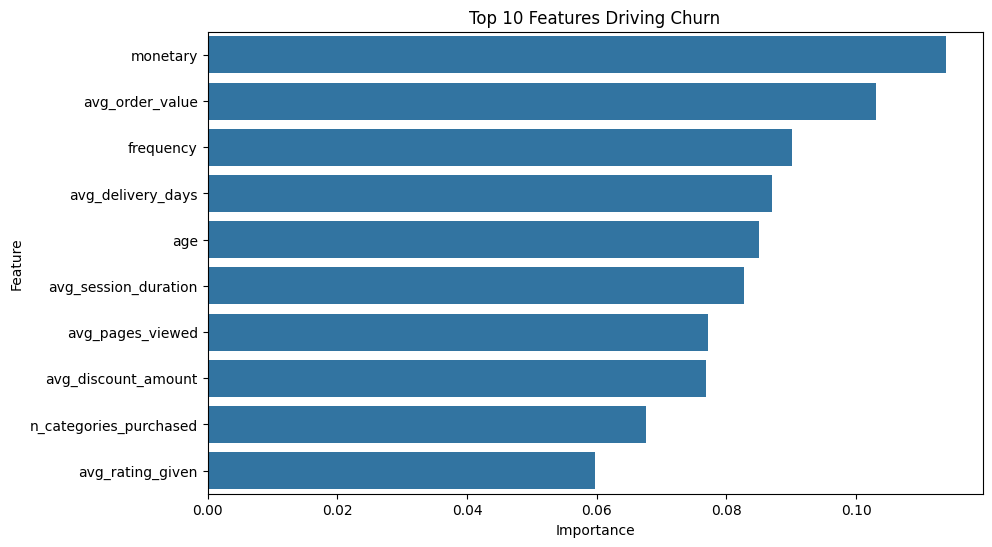

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Features Driving Churn")
plt.show()

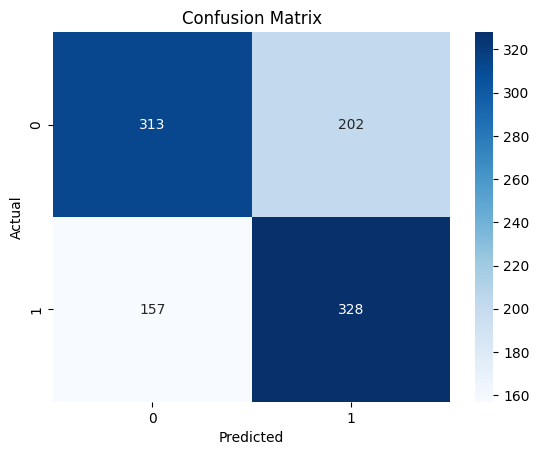

In [48]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
customer_df.head()

,Customer_ID,frequency,monetary,avg_discount_amount,avg_session_duration,avg_pages_viewed,avg_delivery_days,avg_rating_given,n_categories_purchased,age,...,avg_order_value,recency_days,Churn,gender_encoded,pct_mobile_orders,pct_orders_discounted,preferred_payment_Cash on Delivery,preferred_payment_Credit Card,preferred_payment_Debit Card,preferred_payment_Digital Wallet
0,CUST_00001,3,2199.63,46.016667,14.333333,9.000000,9.333333,3.333333,3,40,...,733.210000,111,1,1.0,66.666667,33.333333,False,True,False,False
1,CUST_00002,2,809.90,35.525000,15.000000,10.000000,5.000000,4.000000,2,33,...,404.950000,283,1,1.0,50.000000,50.000000,False,True,False,False
2,CUST_00003,2,3030.81,0.000000,10.500000,8.500000,6.000000,3.500000,2,42,...,1515.405000,82,0,1.0,0.000000,0.000000,False,True,False,False
3,CUST_00004,1,383.22,97.780000,16.000000,15.000000,4.000000,5.000000,1,53,...,383.220000,41,0,1.0,0.000000,100.000000,False,True,False,False
4,CUST_00005,3,2422.73,0.000000,12.666667,9.333333,5.666667,3.666667,3,32,...,807.576667,278,1,1.0,66.666667,0.000000,False,True,False,False


In [51]:
X = customer_df.drop(['Customer_ID', 'Churn'], axis=1)
y = customer_df['Churn']

In [52]:
y.value_counts()

Churn
1    2548
0    2452
Name: count, dtype: int64

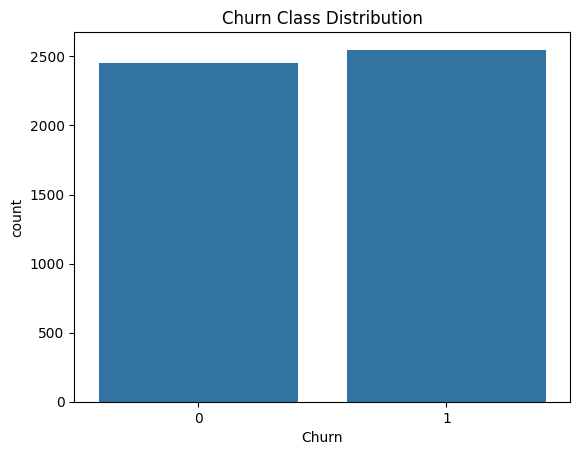

In [53]:
sns.countplot(x=y)
plt.title("Churn Class Distribution")
plt.show()

In [54]:
from imblearn.over_sampling import SMOTE

In [56]:
X.dtypes

frequency                               int64
monetary                              float64
avg_discount_amount                   float64
avg_session_duration                  float64
avg_pages_viewed                      float64
avg_delivery_days                     float64
avg_rating_given                      float64
n_categories_purchased                  int64
age                                     int64
is_returning                             bool
avg_order_value                       float64
recency_days                            int64
gender_encoded                        float64
pct_mobile_orders                     float64
pct_orders_discounted                 float64
preferred_payment_Cash on Delivery       bool
preferred_payment_Credit Card            bool
preferred_payment_Debit Card             bool
preferred_payment_Digital Wallet         bool
dtype: object

In [57]:
X = pd.get_dummies(X, drop_first=True)

In [60]:
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression())
])

In [63]:
X.isnull().sum()

frequency                              0
monetary                               0
avg_discount_amount                    0
avg_session_duration                   0
avg_pages_viewed                       0
avg_delivery_days                      0
avg_rating_given                       0
n_categories_purchased                 0
age                                    0
is_returning                           0
avg_order_value                        0
recency_days                           0
gender_encoded                        73
pct_mobile_orders                      0
pct_orders_discounted                  0
preferred_payment_Cash on Delivery     0
preferred_payment_Credit Card          0
preferred_payment_Debit Card           0
preferred_payment_Digital Wallet       0
dtype: int64

In [64]:
X = X.fillna(X.median(numeric_only=True))

In [65]:
X.isnull().sum().sum()

np.int64(0)

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [67]:
y_resampled.value_counts()

Churn
1    2548
0    2548
Name: count, dtype: int64

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [69]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
y_pred_log = log_model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9774509803921568
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       530
           1       0.98      0.98      0.98       490

    accuracy                           0.98      1020
   macro avg       0.98      0.98      0.98      1020
weighted avg       0.98      0.98      0.98      1020



In [72]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [73]:
y_pred_rf = rf_model.predict(X_test)

In [74]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       530
           1       1.00      1.00      1.00       490

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020



In [75]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [77]:
y_pred_xgb = xgb_model.predict(X_test)

In [78]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       530
           1       1.00      1.00      1.00       490

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020



In [79]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.977451
1,Random Forest,1.000000
2,XGBoost,1.000000


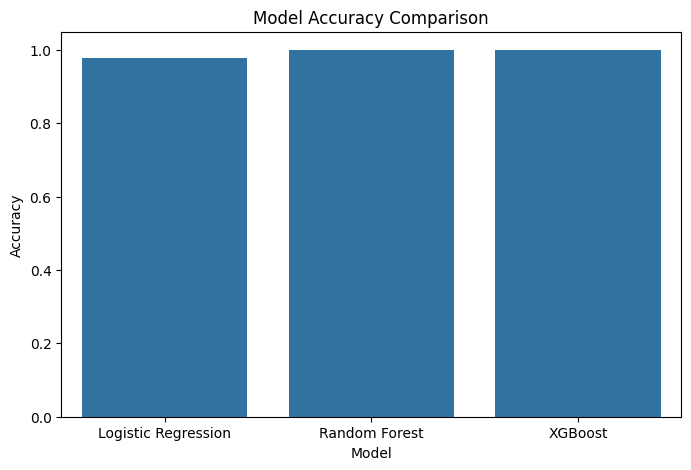

In [80]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=model_comparison
)

plt.title("Model Accuracy Comparison")
plt.show()

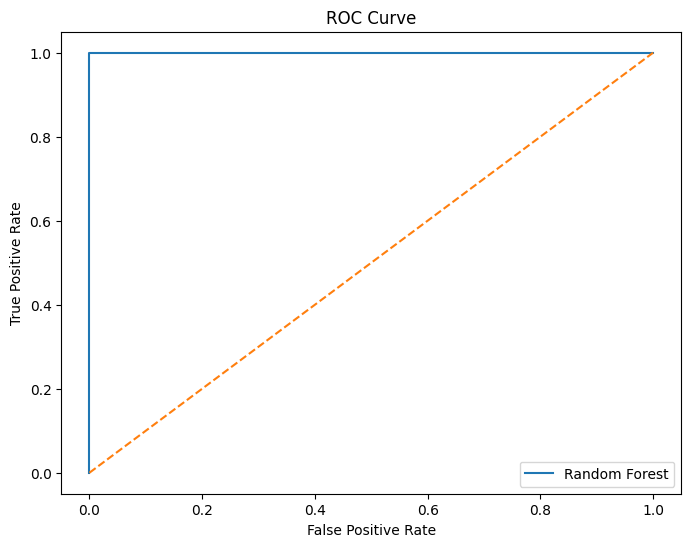

AUC Score: 1.0


In [81]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1], [0,1], linestyle='--')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob_rf))

In [82]:
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

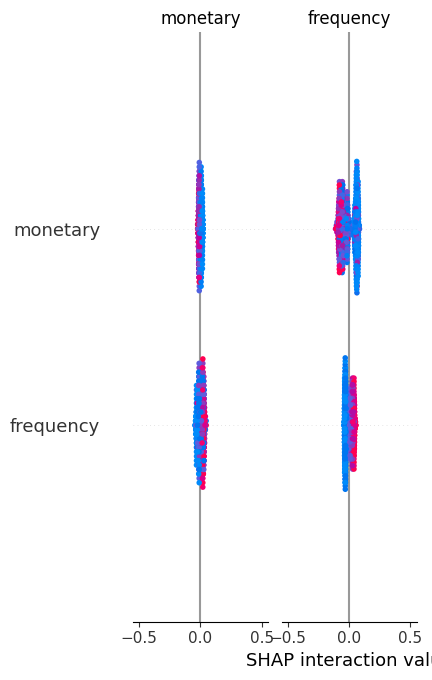

In [85]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [87]:
revenue_df = df.groupby('Customer_ID').agg({
    'Total_Spend': 'first',
    'Order_ID': 'nunique',
    'Session_Duration_Minutes': 'mean',
    'Pages_Viewed': 'mean',
    'Delivery_Time_Days': 'mean',
    'Customer_Rating': 'mean',
    'Discount_Amount': 'mean',
    'Age': 'first',
    'Is_Returning_Customer': 'first',
    'Product_Category': 'nunique'
}).reset_index()

In [88]:
revenue_df.columns = [
    'Customer_ID',
    'target_revenue',
    'frequency',
    'avg_session_duration',
    'avg_pages_viewed',
    'avg_delivery_days',
    'avg_rating',
    'avg_discount',
    'age',
    'is_returning',
    'n_categories'
]

In [89]:
revenue_df.head()

,Customer_ID,target_revenue,frequency,avg_session_duration,avg_pages_viewed,avg_delivery_days,avg_rating,avg_discount,age,is_returning,n_categories
0,CUST_00001,29.18,3,14.333333,9.000000,9.333333,3.333333,46.016667,40,True,3
1,CUST_00002,346.50,2,15.000000,10.000000,5.000000,4.000000,35.525000,33,True,2
2,CUST_00003,396.56,2,10.500000,8.500000,6.000000,3.500000,0.000000,42,False,2
3,CUST_00004,481.00,1,16.000000,15.000000,4.000000,5.000000,97.780000,53,False,1
4,CUST_00005,1601.01,3,12.666667,9.333333,5.666667,3.666667,0.000000,32,False,3


In [90]:
revenue_df.shape

(5000, 11)

In [91]:
X_rev = revenue_df.drop(['Customer_ID', 'target_revenue'], axis=1)
y_rev = revenue_df['target_revenue']

In [92]:
from sklearn.model_selection import train_test_split

X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(
    X_rev,
    y_rev,
    test_size=0.2,
    random_state=42
)

In [93]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_rev, y_train_rev)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
y_pred_lr = lr_model.predict(X_test_rev)

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test_rev, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_rev, y_pred_lr)))
print("R2 Score:", r2_score(y_test_rev, y_pred_lr))

MAE: 1315.7450501563837
RMSE: 2520.673930491241
R2 Score: 0.08944025893405527


In [96]:
from sklearn.ensemble import RandomForestRegressor

rf_reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg_model.fit(X_train_rev, y_train_rev)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [97]:
y_pred_rf_reg = rf_reg_model.predict(X_test_rev)

In [98]:
print("MAE:", mean_absolute_error(y_test_rev, y_pred_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_rev, y_pred_rf_reg)))
print("R2 Score:", r2_score(y_test_rev, y_pred_rf_reg))

MAE: 1413.1123814
RMSE: 2554.2217038297313
R2 Score: 0.06504160199478348


In [99]:
feature_importance_rev = pd.DataFrame({
    'Feature': X_rev.columns,
    'Importance': rf_reg_model.feature_importances_
})

feature_importance_rev = feature_importance_rev.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_rev.head(10)

,Feature,Importance
5,avg_discount,0.285817
6,age,0.148425
3,avg_delivery_days,0.119791
2,avg_pages_viewed,0.115106
1,avg_session_duration,0.113545
4,avg_rating,0.094072
0,frequency,0.049458
8,n_categories,0.048636
7,is_returning,0.025149


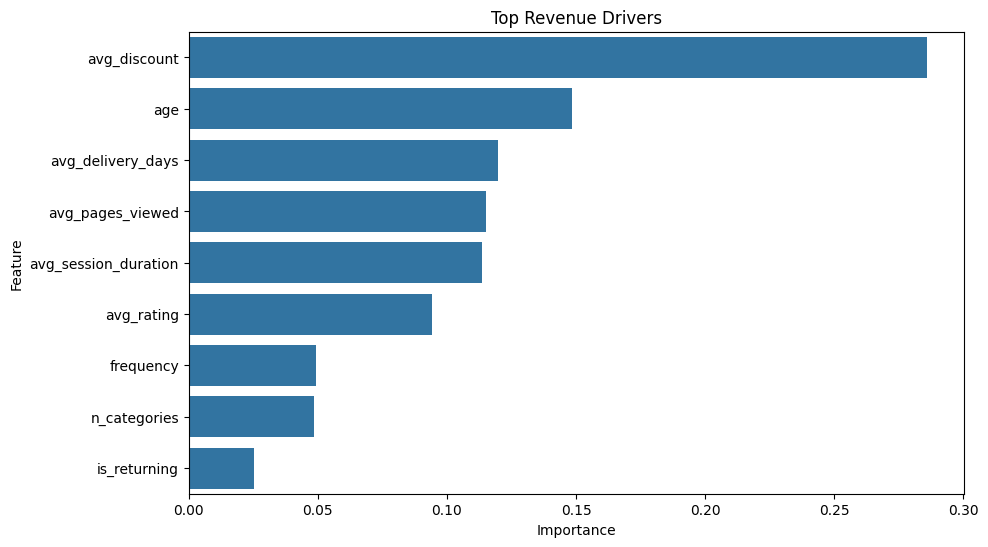

In [100]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_rev
)

plt.title("Top Revenue Drivers")
plt.show()

In [101]:
customer_df['customer_priority'] = pd.qcut(
    customer_df['monetary'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

In [102]:
customer_df['customer_priority'].value_counts()

customer_priority
Low Value       1667
High Value      1667
Medium Value    1666
Name: count, dtype: int64

In [103]:
pd.crosstab(
    customer_df['customer_priority'],
    customer_df['Churn']
)

Churn,0,1
customer_priority,,
Low Value,566,1101
Medium Value,837,829
High Value,1049,618


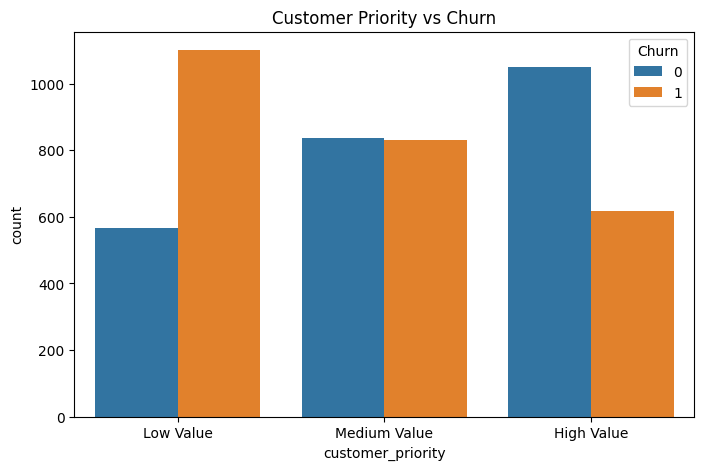

In [104]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='customer_priority',
    hue='Churn',
    data=customer_df
)

plt.title("Customer Priority vs Churn")
plt.show()